In [ ]:
#map the strain name and the phenotypes in the correct order 
import pandas as pd

# Load the first CSV file
csv1_path = "path/to/input/strain_order.csv"
df1 = pd.read_csv(csv1_path)

# Load the second CSV file
csv2_path = "path/to/input/phenotype_values.csv"
df2 = pd.read_csv(csv2_path)

# Create a new DataFrame with the first column of the first CSV
new_df = pd.DataFrame()
new_df['Column1'] = df1.iloc[:, 0]

# Create a dictionary from the first and second columns of the second CSV
df2_dict = df2.set_index(df2.columns[0]).iloc[:, 0].to_dict()

# Map the values from the second CSV to the new DataFrame
new_df['Column2'] = new_df['Column1'].map(df2_dict)

# Save the new DataFrame to a new CSV file
new_csv_path = "path/to/output/ordered_phenotypes.csv"
new_df.to_csv(new_csv_path, index=False)

print(f"New CSV saved to: {new_csv_path}")


## Yeo–Johnson transformation — categorical phenotype

In this project workflow, the Yeo–Johnson transformation was used for the phenotype designated as categorical.

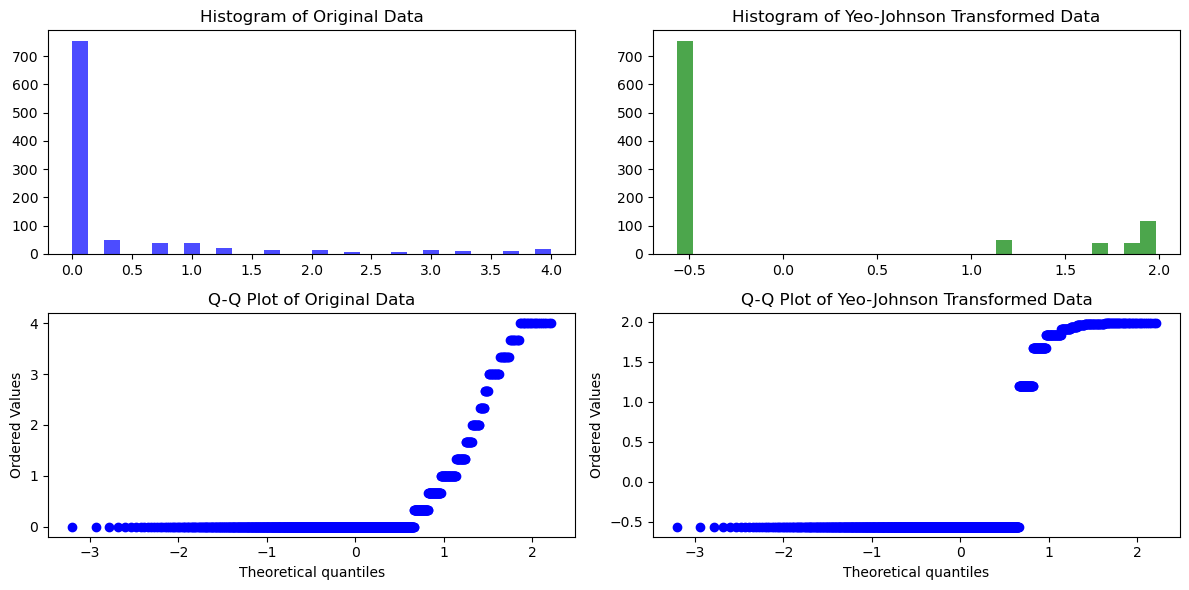

Yeo-Johnson transformed data saved to 'path/to/categorical_phenotype_yeojohnson_transformed.csv'


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import PowerTransformer

# Function to read the file and apply Yeo-Johnson transformation
def apply_yeojohnson_transformation(file_path, delimiter=','):
    # Read the data from the text file
    data = pd.read_csv(file_path, delimiter=delimiter, header=None)
    
    # Extract the third column (index 2), starting from the second row
    original_data = data.iloc[1:, 2].values
    
    # Ensure all data except -9 are numeric
    original_data = pd.to_numeric(original_data, errors='coerce')
    
    # Filter out the data with value -9 or NaN
    mask = (original_data != -9) & (~np.isnan(original_data))
    filtered_data = original_data[mask].reshape(-1, 1)
    
    # Apply Yeo-Johnson transformation
    transformer = PowerTransformer(method='yeo-johnson')
    transformed_data = transformer.fit_transform(filtered_data)
    
    # Place the transformed data back, keeping -9 values unchanged
    transformed_full_data = original_data.copy()
    transformed_full_data[mask] = transformed_data.flatten()
    
    # Plot original data histogram
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 2, 1)
    plt.hist(original_data, bins=30, color='blue', alpha=0.7)
    plt.title('Histogram of Original Data')
    
    # Plot transformed data histogram
    plt.subplot(2, 2, 2)
    plt.hist(transformed_full_data, bins=30, color='green', alpha=0.7)
    plt.title('Histogram of Yeo-Johnson Transformed Data')
    
    # Create Q-Q plot for original data
    plt.subplot(2, 2, 3)
    stats.probplot(original_data, dist="norm", plot=plt)
    plt.title('Q-Q Plot of Original Data')
    
    # Create Q-Q plot for transformed data
    plt.subplot(2, 2, 4)
    stats.probplot(transformed_full_data, dist="norm", plot=plt)
    plt.title('Q-Q Plot of Yeo-Johnson Transformed Data')
    
    plt.tight_layout()
    plt.show()
    
    # Save the transformed data back to the DataFrame, starting from the second row
    data.iloc[1:, 2] = transformed_full_data
    
    # Save the DataFrame to a new CSV file
    transformed_file_path = file_path.replace('.csv', '_yeojohnson_transformed.csv')
    data.to_csv(transformed_file_path, index=False, header=False)
    print(f"Yeo-Johnson transformed data saved to '{transformed_file_path}'")

# Specify the path to your csv file
file_path = "path/to/input/categorical_phenotype.csv"

# Call the function to apply Yeo-Johnson transformation
apply_yeojohnson_transformation(file_path)


## Quantile normalization — continuous phenotype

In this project workflow, quantile normalization was used for the continuous phenotype.

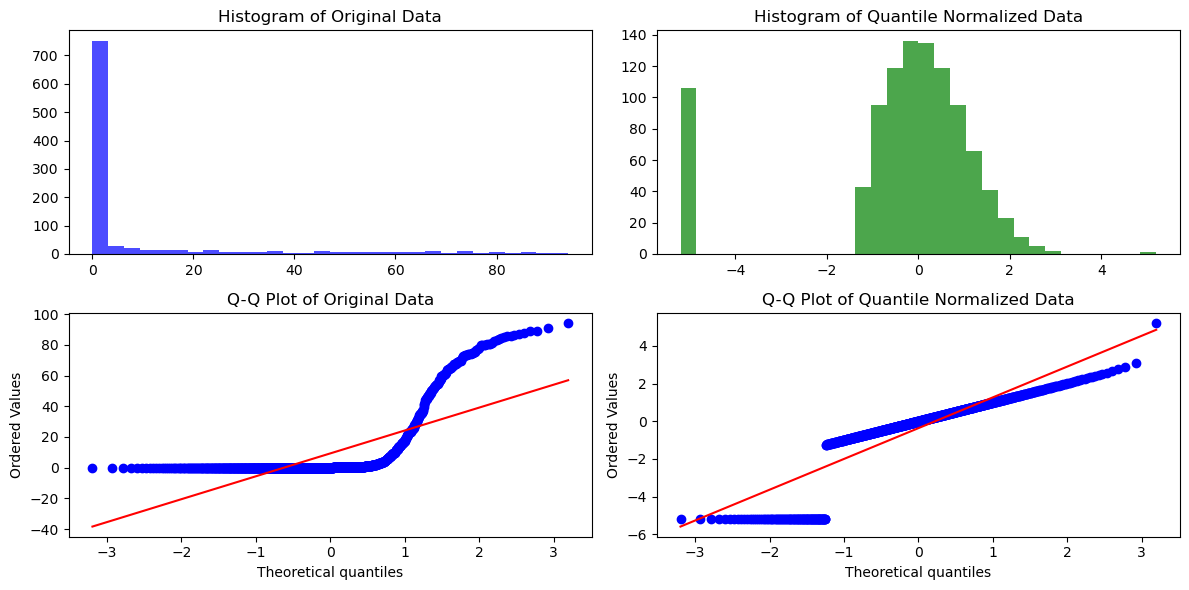

Quantile normalized data saved to 'path/to/continuous_phenotype_quantile_normalized.csv'


In [1]:
#quantile normalization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import QuantileTransformer

# Function to read the file and apply quantile normalization
def apply_quantile_normalization(file_path, delimiter=','):
    # Read the data from the text file
    data = pd.read_csv(file_path, delimiter=delimiter, header=None)
    
    # Preserve the first row
    first_row = data.iloc[0, :].copy()
    
    # Extract the third column (index 2) and identify rows with -9 or NaN
    original_data = pd.to_numeric(data.iloc[1:, 2], errors='coerce')
    
    # Identify valid numeric data (excluding -9 and NaN)
    mask = (original_data != -9) & (~original_data.isna())
    valid_data = original_data[mask].values.reshape(-1, 1)
    
    # Apply quantile normalization only to valid data
    transformer = QuantileTransformer(output_distribution='normal', n_quantiles=valid_data.shape[0], random_state=0)

    normalized_valid_data = transformer.fit_transform(valid_data).flatten()
    
    # Replace the valid data in the original array with the normalized data
    normalized_data = original_data.copy()
    normalized_data[mask] = normalized_valid_data
    
    # Plot original data histogram
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 2, 1)
    plt.hist(valid_data, bins=30, color='blue', alpha=0.7)
    plt.title('Histogram of Original Data')
    
    # Plot normalized data histogram
    plt.subplot(2, 2, 2)
    plt.hist(normalized_valid_data, bins=30, color='green', alpha=0.7)
    plt.title('Histogram of Quantile Normalized Data')
    
    # Create Q-Q plot for original data
    plt.subplot(2, 2, 3)
    stats.probplot(valid_data.flatten(), dist="norm", plot=plt)
    plt.title('Q-Q Plot of Original Data')
    
    # Create Q-Q plot for normalized data
    plt.subplot(2, 2, 4)
    stats.probplot(normalized_valid_data, dist="norm", plot=plt)
    plt.title('Q-Q Plot of Quantile Normalized Data')
    
    plt.tight_layout()
    plt.show()
    
    # Save the normalized data back to the DataFrame, keeping the first row unchanged
    data.iloc[1:, 2] = normalized_data
    
    # Reinsert the first row
    data.iloc[0, :] = first_row
    
    # Save the DataFrame to a new CSV file
    normalized_file_path = file_path.replace('.csv', '_quantile_normalized.csv')
    data.to_csv(normalized_file_path, index=False, header=False)
    print(f"Quantile normalized data saved to '{normalized_file_path}'")

# Specify the path to your text file
file_path = "path/to/input/continuous_phenotype.csv"

# Call the function to apply quantile normalization
apply_quantile_normalization(file_path)


In [3]:
#csv to txt
import pandas as pd

# Load the CSV file
csv_file = "path/to/input/continuous_phenotype_quantile_normalized.csv"
df = pd.read_csv(csv_file)

# Save as a space-delimited text file with proper spacing
txt_file = "path/to/output/continuous_phenotype_quantile_normalized.txt"
df.to_csv(txt_file, sep=' ', index=False, header=False, float_format='%.6f')

# Ensuring columns are properly spaced
with open(txt_file, 'r') as file:
    lines = file.readlines()

with open(txt_file, 'w') as file:
    for line in lines:
        columns = line.strip().split()
        file.write(' '.join(f"{col:15}" for col in columns) + '\n')
